<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_no_churn"] = df_collection["formated_table"].drop('churn', axis=1)
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["formated_table_with_keys_no_churn"] = get_table_with_keys(df_collection["formated_table_no_churn"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys_no_churn"], n)

df_collection["formated_table_with_keys_no_churn"].head

<bound method NDFrame.head of            key1            credit_score          country       key2  \
0         key_1       Credit_Score_Fair   Country_France      key_1   
1         key_2       Credit_Score_Fair    Country_Spain      key_2   
2         key_3       Credit_Score_Poor   Country_France      key_3   
3         key_4       Credit_Score_Good   Country_France      key_4   
4         key_5  Credit_Score_Excellent    Country_Spain      key_5   
...         ...                     ...              ...        ...   
9995   key_9996  Credit_Score_Very_Good   Country_France   key_9996   
9996   key_9997       Credit_Score_Poor   Country_France   key_9997   
9997   key_9998       Credit_Score_Good   Country_France   key_9998   
9998   key_9999  Credit_Score_Very_Good  Country_Germany   key_9999   
9999  key_10000  Credit_Score_Very_Good   Country_France  key_10000   

             gender                        age       key3     tenure  \
0     Gender_Female  Age_Adults_in_their_Prim

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path
seeds = [1, 42, 66]
models = {}  

for seed in seeds:
    base_config = ModelConfig(
        vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    
    GRID = {
        "vector_size": [50, 100, 150, 200, 300],
        "window": [2, 4, 6, 10, 15, 20],
        "sg": [0, 1],
        "epochs": [30],
        "negative": [5],
        "sample": [1e-3],
        "hs": [0],
        "alpha": [0.025],
        "seed": [seed]
    }
    
    trainer = ModelTrainer()
    repository = ModelRepository(base_dir=Path.cwd())
    runner = ExperimentRunner(trainer, repository, base_config)
    
    
    models[seed]  = runner.run_grid_search(
        sentences=df_collection["n_sentences"]["20"],
        param_grid=GRID,
        #n_sentences_tokenized=df_collection["n_sentences"],
        num_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )

Started Model-Creation with: CBOW, vs=50, win=2, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_2_ep_30_nsent_10000_sentlen_300_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=2, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_2_ep_30_nsent_10000_sentlen_300_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_300_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_300_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=6, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_6_ep_30_nsent_10000_sentlen_300_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {} 
for seed in seeds:
    average_sentence_vectors[seed] = []
    for model in models[seed]:
        average_sentence_vectors[seed].append([create_average_sentence_vectors(model, df_collection["formated_table_with_keys"], base_dir = Path.cwd(), verbose=False),model[1]])
    print("Finished for Seed: ", seed)

[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 'Gender_Female', 'Age_Adults_in_their_Prime', 'Tenure_2', 'Balance_Cluster_1', 'ProductsNumber_1', 'CreditCard_Yes', 'ActiveMember_Yes', 'Salary_High']
[DEBUG] feature_names (key_values_filtered) length: 11
[DEBUG] first 20 feature_names: ['key_1', 'Credit_Score_Fair', 'Country_France', 

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_grid_results
    
test_results = get_all_grid_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

Tests abgeschlossen. 60 Modelle getestet.


In [5]:
import pandas as pd
rows = []
#print(test_results)
for r in test_results:
    p = r["params"]
    rows.append({
        "vector_size": p["Vector Size"],
        "window": p["Window"],
        "algorithm": p["Algorithmus"],
        "ssmq": r["ssmq"],
        "sc": r["nd_norm"],
        "rs": r["rs_mean"],
        "fc": r["fc"]
    })

df = pd.DataFrame(rows)
#df.head

<h2>Visualisierung<h2>

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

def render_figure(fig, name, dpi=300, show=True):
    """
    Centralized figure handling:
    - saves in publication-quality formats
    - optionally displays in Jupyter
    - closes figure to avoid memory leaks
    """
    fig.savefig(FIGURE_DIR / f"{name}.pdf")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=dpi)

    if show:
        plt.show()

    plt.close(fig)

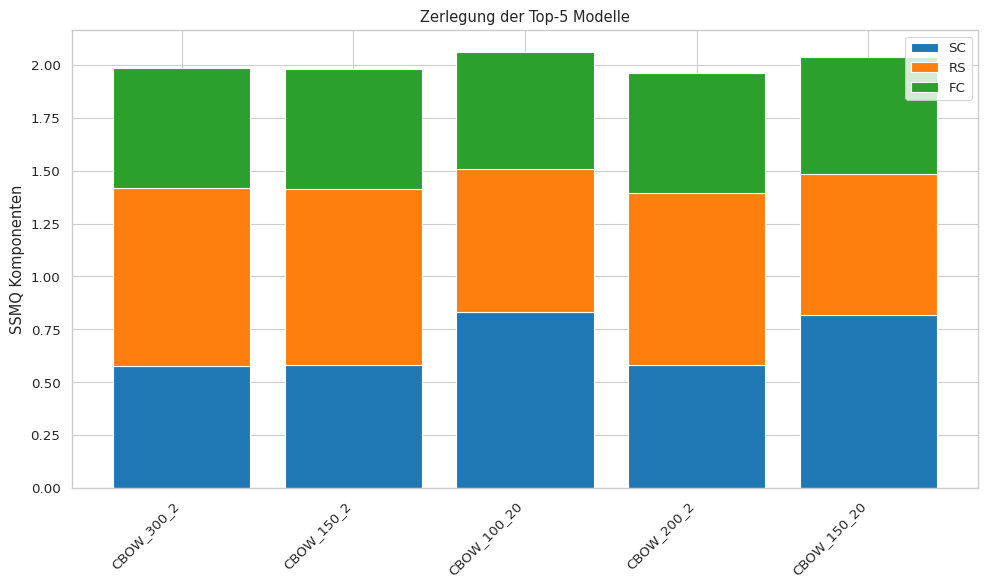

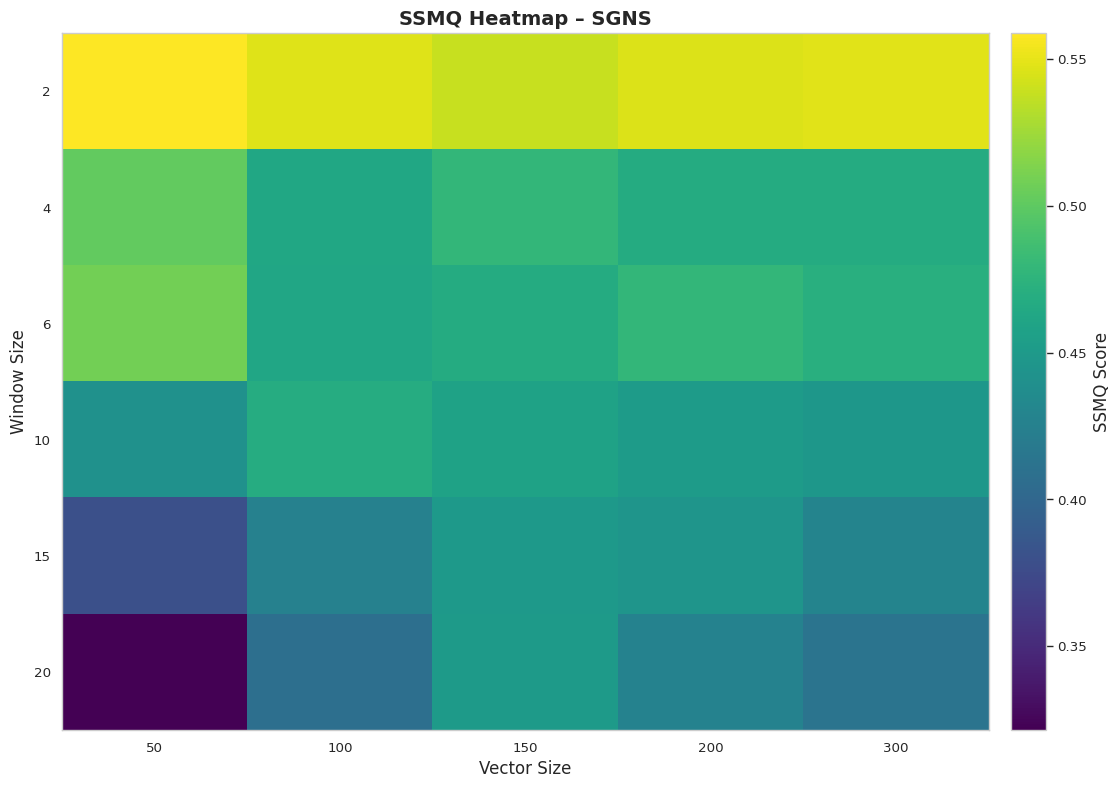

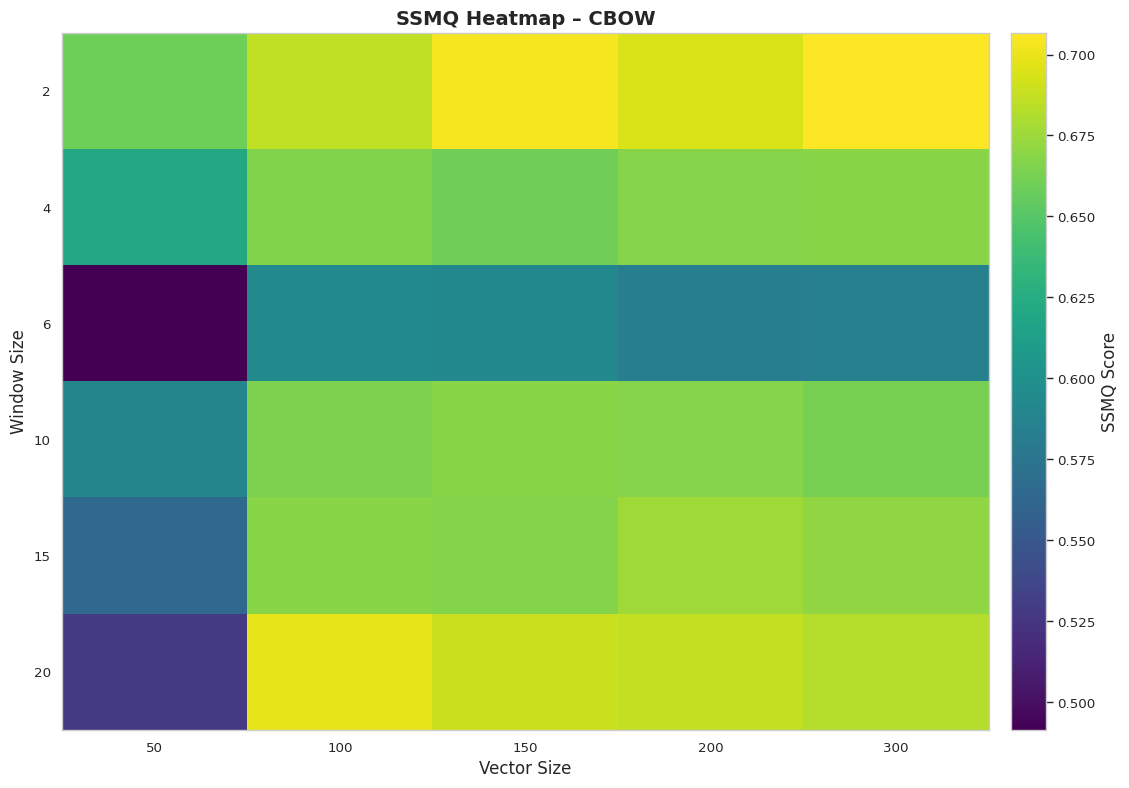

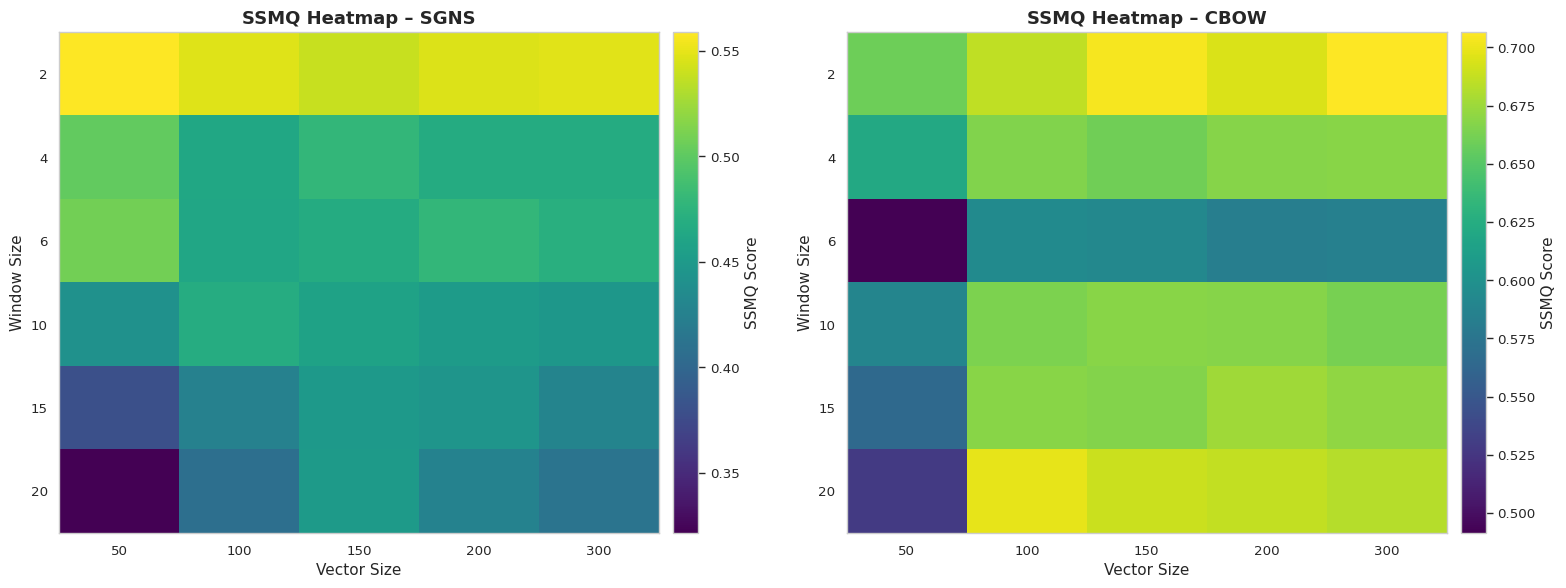

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Wrapper-Methode
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

def render_figure(fig, name, dpi=300, show=True):
    """
    Centralized figure handling:
    - saves in publication-quality formats
    - optionally displays in Jupyter
    - closes figure to avoid memory leaks
    """
    fig.savefig(FIGURE_DIR / f"{name}.pdf")
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=dpi)

    if show:
        plt.show()

    plt.close(fig)

# Sortieren der Daten
df_sorted = df.sort_values(by='ssmq', ascending=False)
top5 = df_sorted.head(5)

# 1. Balkendiagramm - Top-5 Modelle
fig1 = plt.figure(figsize=(10, 6))
plt.bar(range(5), top5["sc"], label="SC")
plt.bar(range(5), top5["rs"], bottom=top5["sc"], label="RS")
plt.bar(
    range(5),
    top5["fc"],
    bottom=top5["sc"] + top5["rs"],
    label="FC"
)

plt.xticks(
    range(5),
    top5["algorithm"] + "_" +
    top5["vector_size"].astype(str) + "_" +
    top5["window"].astype(str),
    rotation=45,
    ha='right'
)
plt.ylabel("SSMQ Komponenten")
plt.title("Zerlegung der Top-5 Modelle")
plt.legend()
plt.tight_layout()

# Speichern und anzeigen
render_figure(fig1, "top5_models_decomposition", show=True)

# 2. GETRENNTE Heatmaps mit individuellen Skalen
# Daten für SGNS und CBOW vorbereiten
sgns = df[df["algorithm"] == "SGNS"]
cbow = df[df["algorithm"] == "CBOW"]

heatmap_sgns = sgns.pivot(
    index="window",
    columns="vector_size",
    values="ssmq"
)

heatmap_cbow = cbow.pivot(
    index="window",
    columns="vector_size",
    values="ssmq"
)

# Individuelle Werteskalen für jede Heatmap
# Sicherstellen, dass NaN-Werte ignoriert werden
sgns_values = heatmap_sgns.values[~np.isnan(heatmap_sgns.values)]
cbow_values = heatmap_cbow.values[~np.isnan(heatmap_cbow.values)]

vmin_sgns = sgns_values.min() if len(sgns_values) > 0 else 0
vmax_sgns = sgns_values.max() if len(sgns_values) > 0 else 1

vmin_cbow = cbow_values.min() if len(cbow_values) > 0 else 0
vmax_cbow = cbow_values.max() if len(cbow_values) > 0 else 1

# Erstelle zwei separate Figuren
# SGNS Heatmap mit eigener Skala
fig_sgns, ax_sgns = plt.subplots(figsize=(12, 8))
im1 = ax_sgns.imshow(heatmap_sgns.values, 
                     vmin=vmin_sgns, 
                     vmax=vmax_sgns, 
                     aspect='auto', 
                     cmap='viridis',
                     interpolation='nearest')

ax_sgns.set_xticks(range(len(heatmap_sgns.columns)))
ax_sgns.set_xticklabels(heatmap_sgns.columns)
ax_sgns.set_yticks(range(len(heatmap_sgns.index)))
ax_sgns.set_yticklabels(heatmap_sgns.index)
ax_sgns.set_xlabel("Vector Size", fontsize=12)
ax_sgns.set_ylabel("Window Size", fontsize=12)
ax_sgns.set_title("SSMQ Heatmap – SGNS", fontsize=14, fontweight='bold')

# Gitter entfernen
ax_sgns.grid(False)

# Colorbar für SGNS
cbar1 = plt.colorbar(im1, ax=ax_sgns, pad=0.02)
cbar1.set_label("SSMQ Score", fontsize=12)

# Zellenwerte anzeigen (optional)
if False:
    for i in range(len(heatmap_sgns.index)):
        for j in range(len(heatmap_sgns.columns)):
            if not np.isnan(heatmap_sgns.iloc[i, j]):
                ax_sgns.text(j, i, f"{heatmap_sgns.iloc[i, j]:.3f}",
                            ha="center", va="center",
                            color="white", fontsize=9, fontweight='bold')

plt.tight_layout()
render_figure(fig_sgns, "heatmap_sgns_separate_scale", show=True)

# CBOW Heatmap mit eigener Skala
fig_cbow, ax_cbow = plt.subplots(figsize=(12, 8))
im2 = ax_cbow.imshow(heatmap_cbow.values, 
                     vmin=vmin_cbow, 
                     vmax=vmax_cbow, 
                     aspect='auto', 
                     cmap='viridis',
                     interpolation='nearest')

ax_cbow.set_xticks(range(len(heatmap_cbow.columns)))
ax_cbow.set_xticklabels(heatmap_cbow.columns)
ax_cbow.set_yticks(range(len(heatmap_cbow.index)))
ax_cbow.set_yticklabels(heatmap_cbow.index)
ax_cbow.set_xlabel("Vector Size", fontsize=12)
ax_cbow.set_ylabel("Window Size", fontsize=12)
ax_cbow.set_title("SSMQ Heatmap – CBOW", fontsize=14, fontweight='bold')

# Gitter entfernen
ax_cbow.grid(False)

# Colorbar für CBOW
cbar2 = plt.colorbar(im2, ax=ax_cbow, pad=0.02)
cbar2.set_label("SSMQ Score", fontsize=12)

# Zellenwerte anzeigen (optional)
if False:
    for i in range(len(heatmap_cbow.index)):
        for j in range(len(heatmap_cbow.columns)):
            if not np.isnan(heatmap_cbow.iloc[i, j]):
                ax_cbow.text(j, i, f"{heatmap_cbow.iloc[i, j]:.3f}",
                            ha="center", va="center",
                            color="white", fontsize=9, fontweight='bold')

plt.tight_layout()
render_figure(fig_cbow, "heatmap_cbow_separate_scale", show=True)

# 3. OPTIONAL: Heatmaps nebeneinander mit getrennten Skalen
# (falls Sie sie trotzdem zusammen sehen möchten)
fig_combined, axes = plt.subplots(1, 2, figsize=(16, 6))

# SGNS
im1 = axes[0].imshow(heatmap_sgns.values, 
                    vmin=vmin_sgns, 
                    vmax=vmax_sgns, 
                    aspect='auto', 
                    cmap='viridis',
                    interpolation='nearest')
axes[0].set_xticks(range(len(heatmap_sgns.columns)))
axes[0].set_xticklabels(heatmap_sgns.columns)
axes[0].set_yticks(range(len(heatmap_sgns.index)))
axes[0].set_yticklabels(heatmap_sgns.index)
axes[0].set_xlabel("Vector Size", fontsize=11)
axes[0].set_ylabel("Window Size", fontsize=11)
axes[0].set_title("SSMQ Heatmap – SGNS", fontsize=13, fontweight='bold')
axes[0].grid(False)  # Gitter entfernen

# Colorbar für SGNS
cbar1_combined = fig_combined.colorbar(im1, ax=axes[0], pad=0.02)
cbar1_combined.set_label("SSMQ Score", fontsize=11)

# CBOW
im2 = axes[1].imshow(heatmap_cbow.values, 
                    vmin=vmin_cbow, 
                    vmax=vmax_cbow, 
                    aspect='auto', 
                    cmap='viridis',
                    interpolation='nearest')
axes[1].set_xticks(range(len(heatmap_cbow.columns)))
axes[1].set_xticklabels(heatmap_cbow.columns)
axes[1].set_yticks(range(len(heatmap_cbow.index)))
axes[1].set_yticklabels(heatmap_cbow.index)
axes[1].set_xlabel("Vector Size", fontsize=11)
axes[1].set_ylabel("Window Size", fontsize=11)
axes[1].set_title("SSMQ Heatmap – CBOW", fontsize=13, fontweight='bold')
axes[1].grid(False)  # Gitter entfernen

# Colorbar für CBOW
cbar2_combined = fig_combined.colorbar(im2, ax=axes[1], pad=0.02)
cbar2_combined.set_label("SSMQ Score", fontsize=11)

plt.tight_layout()
render_figure(fig_combined, "heatmaps_combined_separate_scales", show=True)


SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)

BEST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.7066 | Vec: 300, Win: 2, Epochs: 30
  #2: CBOW | SSMQ: 0.7038 | Vec: 150, Win: 2, Epochs: 30

WORST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.5277 | Vec: 50, Win: 20, Epochs: 30
  #2: CBOW | SSMQ: 0.4915 | Vec: 50, Win: 6, Epochs: 30

BEST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.5589 | Vec: 50, Win: 2, Epochs: 30
  #2: SGNS | SSMQ: 0.5484 | Vec: 300, Win: 2, Epochs: 30

WORST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.3793 | Vec: 50, Win: 15, Epochs: 30
  #2: SGNS | SSMQ: 0.3214 | Vec: 50, Win: 20, Epochs: 30

EXTRACTING WORD AND SENTENCE VECTORS...

CBOW Best Models:
  Model #1:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 300 dims
   Churn: 6111 churned, 23889 not
  Model #2:
   Total: 10051, Filtered: 10000, Kept: 51
   Sentence vectors: 30000 samples, 150 dims
   Churn: 6111 churned, 23889 not

CBOW Worst Models:
  Model #1:
   Total: 10051, Filtered: 10000, Kept:

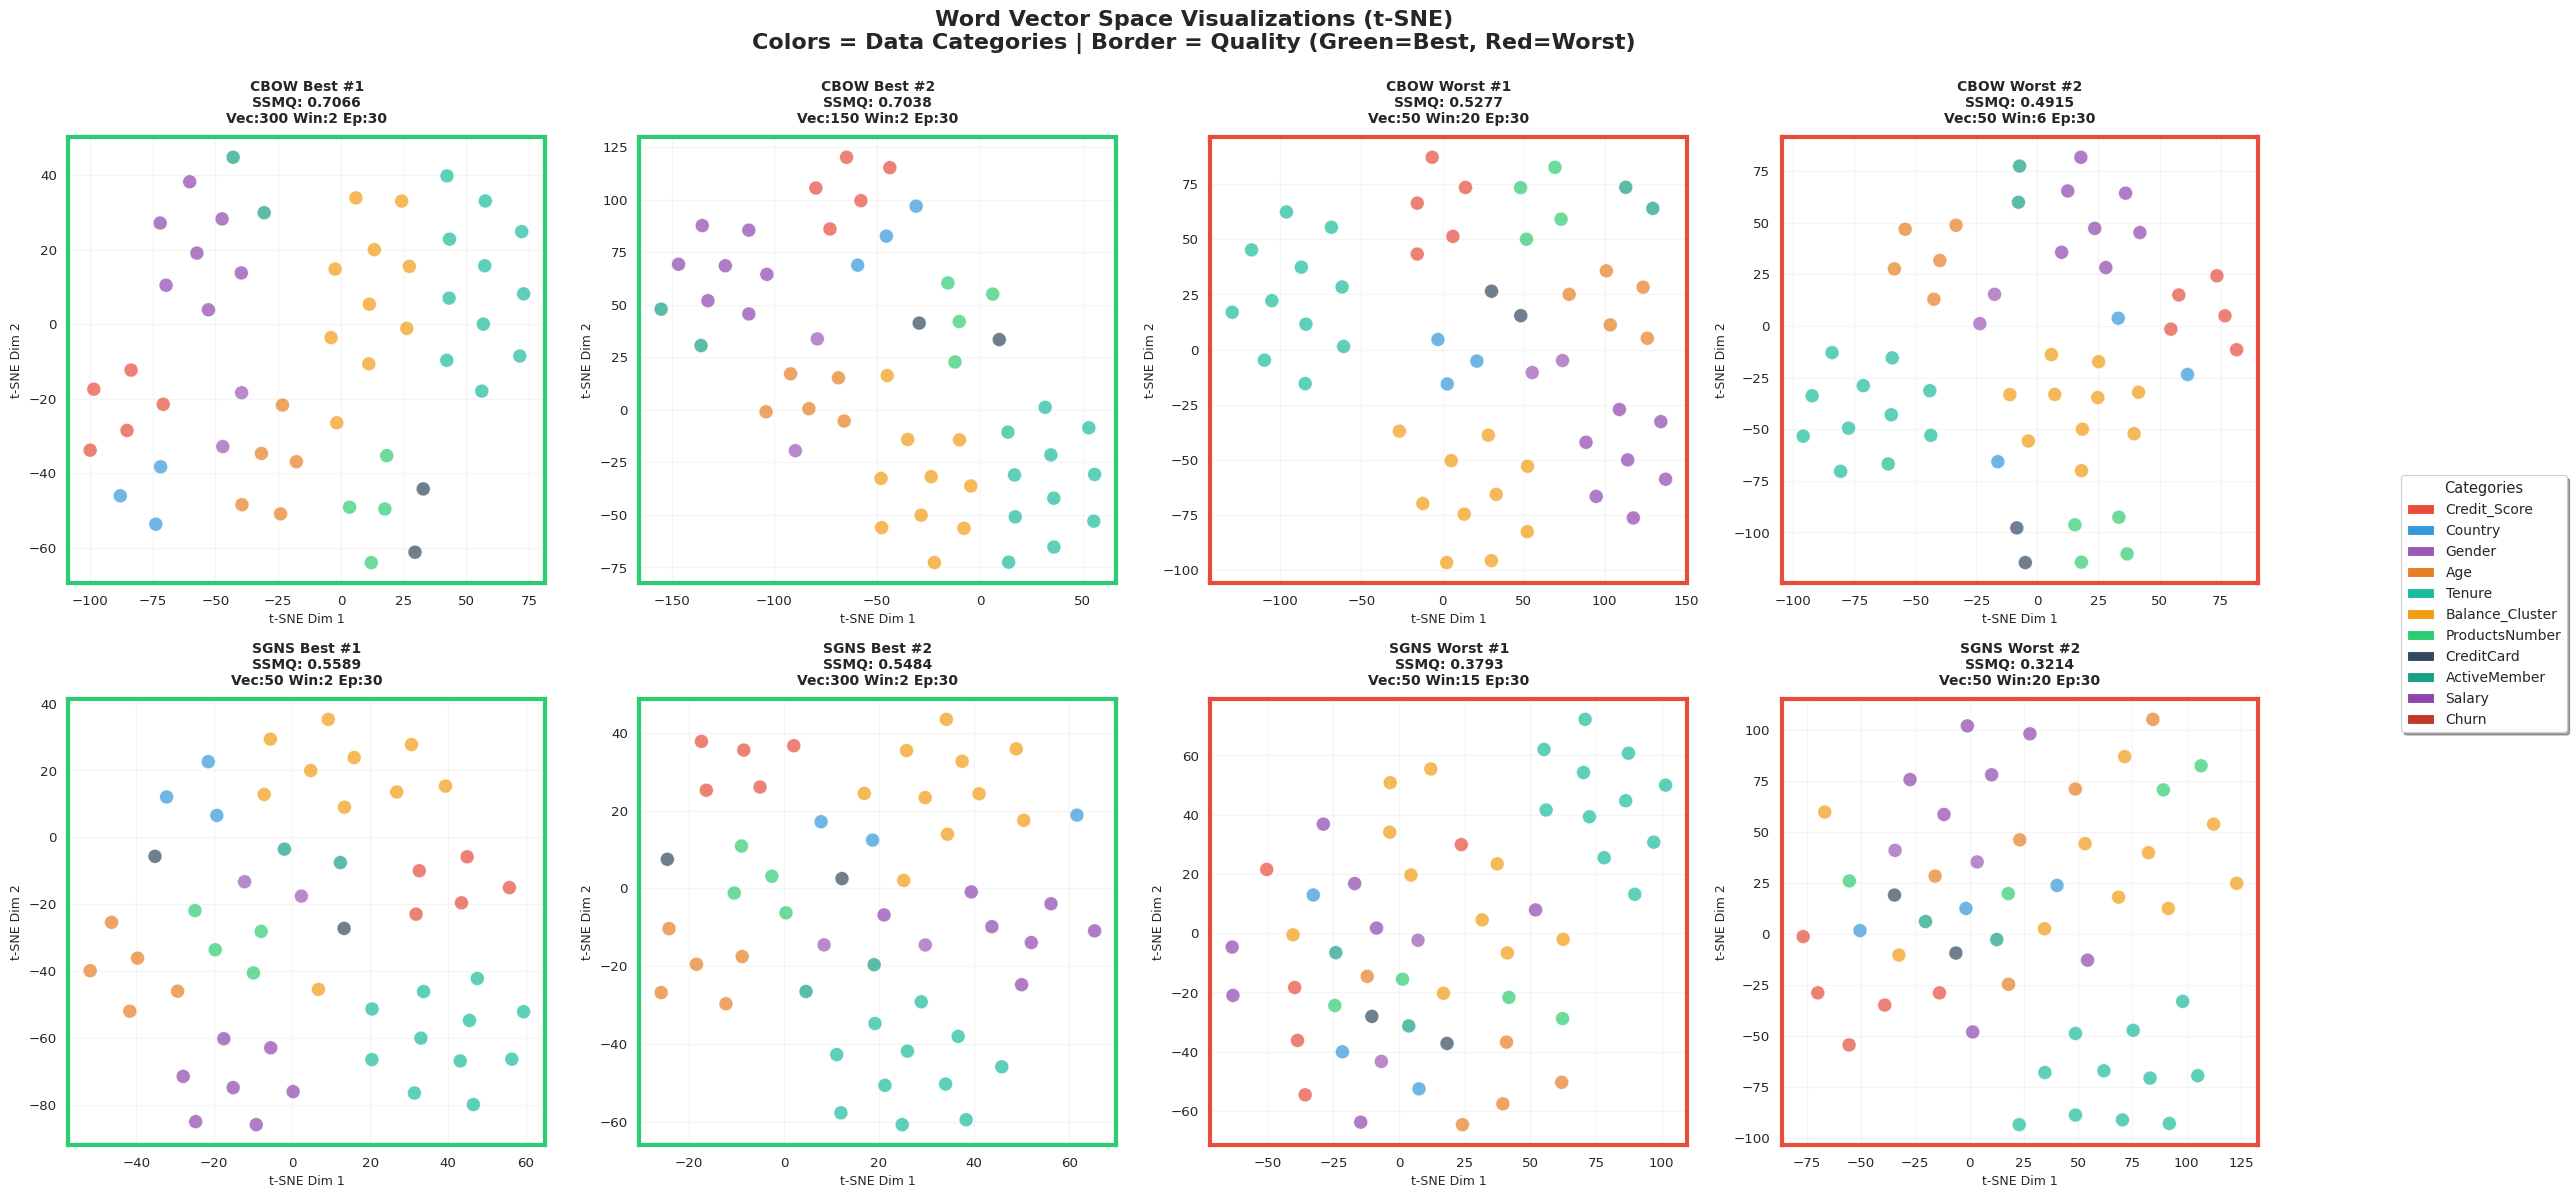


CREATING SENTENCE VECTOR VISUALIZATIONS

  CBOW Best #1: 1500 sentences
  CBOW Best #2: 1500 sentences
  CBOW Worst #1: 1500 sentences
  CBOW Worst #2: 1500 sentences
  SGNS Best #1: 1500 sentences
  SGNS Best #2: 1500 sentences
  SGNS Worst #1: 1500 sentences
  SGNS Worst #2: 1500 sentences


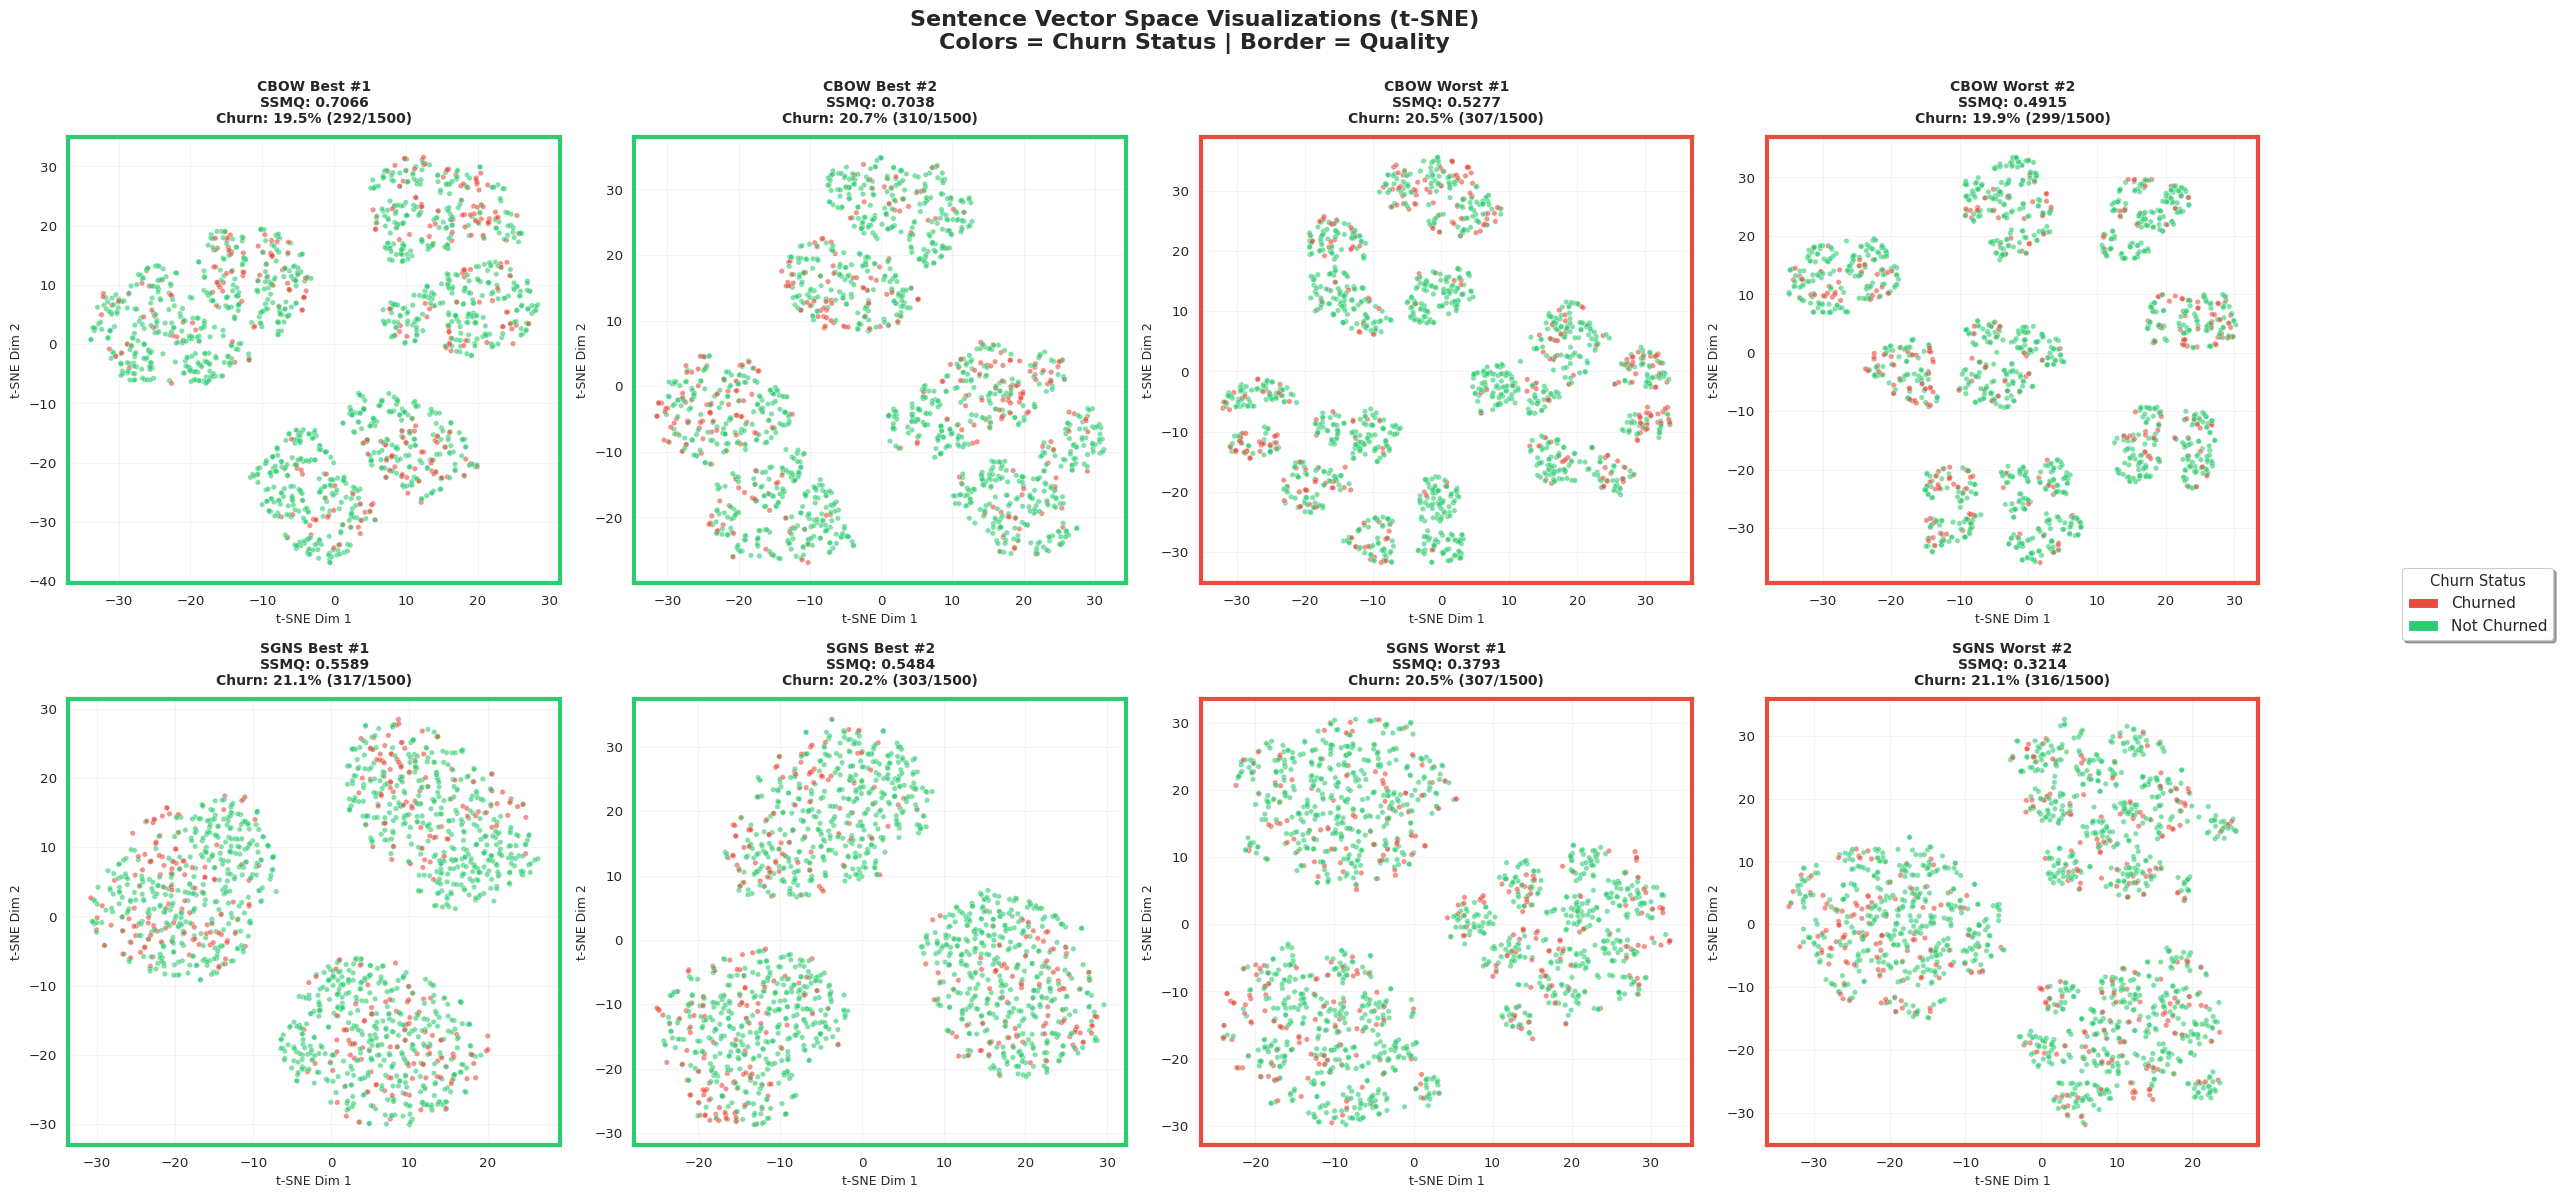

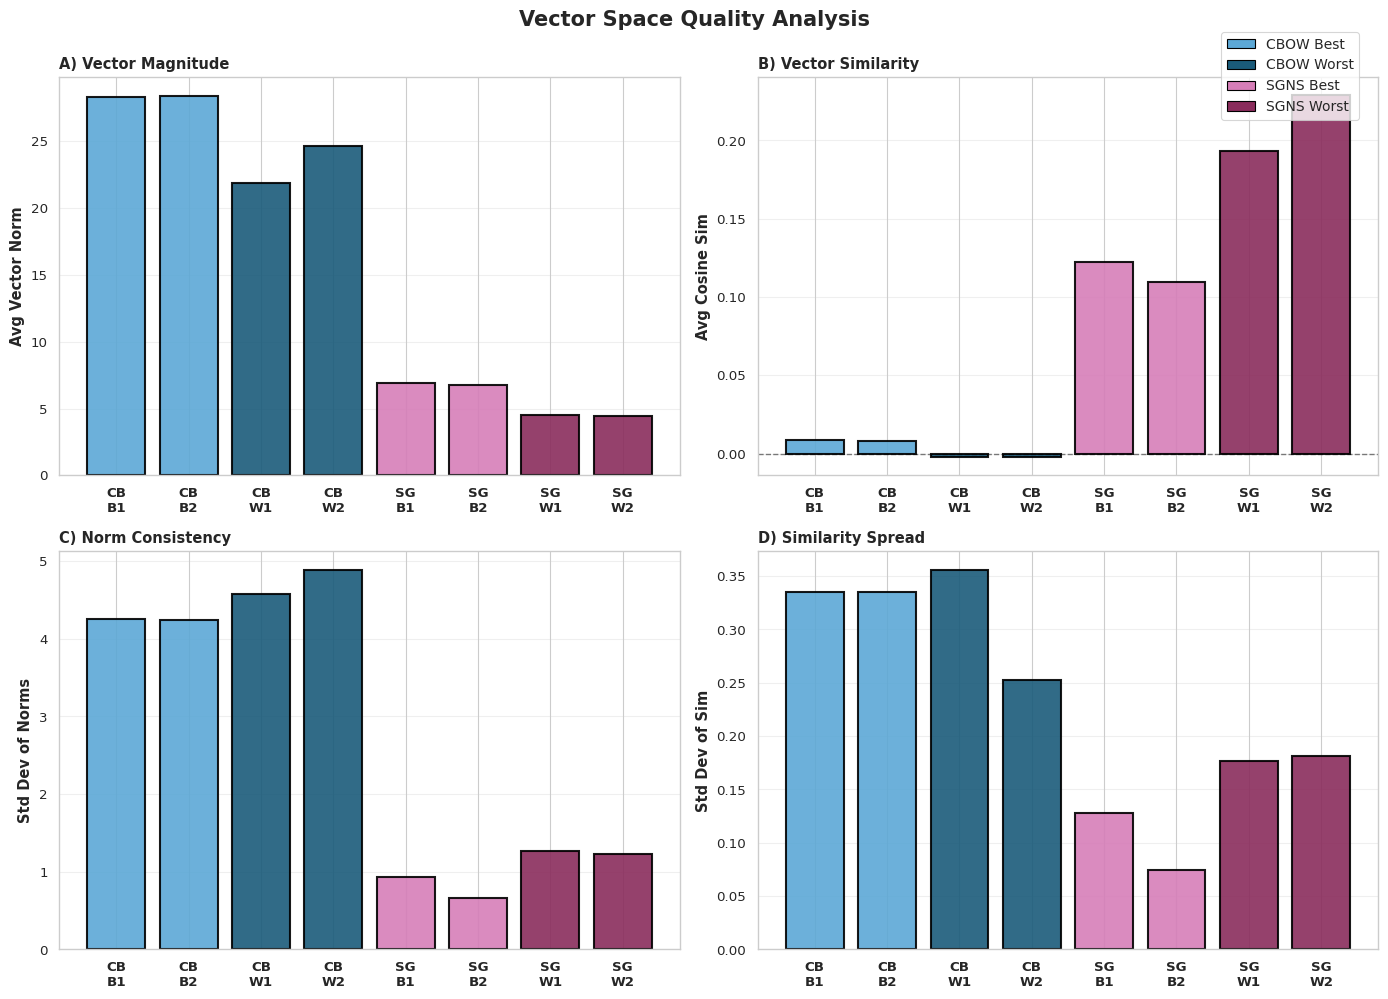


ALGORITHM COMPARISON COMPLETE


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd


# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# ANPASSUNG: test_results in eine Liste konvertieren (falls es ein einzelnes Dict ist)
# ==================================================================================

# Falls test_results ein einzelnes Dictionary ist, in eine Liste konvertieren
if isinstance(test_results, dict):
    test_results = [test_results]

# ==================================================================================
# SCHRITT 1: Finde 2 beste und 2 schlechteste CBOW- und SGNS-Modelle
# ==================================================================================

models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähle 2 beste und 2 schlechteste für jeden Algorithmus
best_2_cbow = cbow_sorted[:2]
worst_2_cbow = cbow_sorted[-2:] if len(cbow_sorted) >= 2 else []
best_2_sgns = sgns_sorted[:2]
worst_2_sgns = sgns_sorted[-2:] if len(sgns_sorted) >= 2 else []

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)")
print("="*100 + "\n")

print("BEST 2 CBOW MODELS:")
for i, model in enumerate(best_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 CBOW MODELS:")
for i, model in enumerate(worst_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nBEST 2 SGNS MODELS:")
for i, model in enumerate(best_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 SGNS MODELS:")
for i, model in enumerate(worst_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

# ==================================================================================
# HILFSFUNKTIONEN (leicht angepasst)
# ==================================================================================

def extract_word_vectors(model_data):
    """Extrahiert Word Vectors und filtert key_* Wörter"""
    result = model_data['result_ref']
    
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            all_vocab = list(model.wv.key_to_index.keys())
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert")
                return None, None
            
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total: {len(all_vocab)}, Filtered: {filtered_count}, Kept: {len(filtered_vocab)}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden")
    return None, None


def extract_sentence_vectors(model_data):
    """Extrahiert Satzvektoren und Churn-Labels (angepasst für neue Struktur)"""
    result = model_data['result_ref']
    if 'used_sentence_vectors' in result and 'data' in result['used_sentence_vectors']:
        data_tuples = result['used_sentence_vectors']['data']
        
        if not data_tuples:
            print(f"   No sentence vectors found")
            return None, None
        
        all_vectors = []
        all_labels = []
        
        for seed_id, df in data_tuples:
            # Überprüfe, ob df ein DataFrame ist
            if isinstance(df, pd.DataFrame):
                vectors = np.array([np.array(v) for v in df['vector'].values])
                labels = df['churned'].values
                all_vectors.append(vectors)
                all_labels.append(labels)
        
        if all_vectors:
            combined_vectors = np.vstack(all_vectors)
            combined_labels = np.concatenate(all_labels)
            
            print(f"   Sentence vectors: {combined_vectors.shape[0]} samples, {combined_vectors.shape[1]} dims")
            print(f"   Churn: {np.sum(combined_labels)} churned, {len(combined_labels) - np.sum(combined_labels)} not")
            
            return combined_vectors, combined_labels
        else:
            print(f"   No valid DataFrames found in data tuples")
    
    print(f"   No sentence vectors available")
    return None, None


def get_category_color(word):
    """Bestimmt Farbe basierend auf Datenkategorie"""
    category_colors = {
        'Credit_Score': '#E74C3C',
        'Country': '#3498DB',
        'Gender': '#9B59B6',
        'Age': '#E67E22',
        'Tenure': '#1ABC9C',
        'Balance_Cluster': '#F39C12',
        'ProductsNumber': '#2ECC71',
        'CreditCard': '#34495E',
        'ActiveMember': '#16A085',
        'Salary': '#8E44AD',
        'Churn': '#C0392B',
    }
    
    parts = word.split('_')
    
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    elif len(parts) >= 1:
        category = parts[0]
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    return category_colors.get(category, '#95A5A6')


def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# ==================================================================================
# DATENEXTRAKTION
# ==================================================================================

# Listen für Word Vectors
cbow_best_vectors, cbow_worst_vectors = [], []
sgns_best_vectors, sgns_worst_vectors = [], []
cbow_best_vocab, cbow_worst_vocab = [], []
sgns_best_vocab, sgns_worst_vocab = [], []

# Listen für Sentence Vectors
cbow_best_sent_vectors, cbow_worst_sent_vectors = [], []
sgns_best_sent_vectors, sgns_worst_sent_vectors = [], []
cbow_best_sent_labels, cbow_worst_sent_labels = [], []
sgns_best_sent_labels, sgns_worst_sent_labels = [], []

print("\n" + "="*100)
print("EXTRACTING WORD AND SENTENCE VECTORS...")
print("="*100 + "\n")

# CBOW Best
print("CBOW Best Models:")
for i, model in enumerate(best_2_cbow):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_best_vectors.append(vectors)
        cbow_best_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        cbow_best_sent_vectors.append(sent_vec)
        cbow_best_sent_labels.append(sent_lab)

# CBOW Worst
print("\nCBOW Worst Models:")
for i, model in enumerate(worst_2_cbow):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_worst_vectors.append(vectors)
        cbow_worst_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        cbow_worst_sent_vectors.append(sent_vec)
        cbow_worst_sent_labels.append(sent_lab)

# SGNS Best
print("\nSGNS Best Models:")
for i, model in enumerate(best_2_sgns):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_best_vectors.append(vectors)
        sgns_best_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        sgns_best_sent_vectors.append(sent_vec)
        sgns_best_sent_labels.append(sent_lab)

# SGNS Worst
print("\nSGNS Worst Models:")
for i, model in enumerate(worst_2_sgns):
    print(f"  Model #{i+1}:")
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_worst_vectors.append(vectors)
        sgns_worst_vocab.append(vocab)
    
    sent_vec, sent_lab = extract_sentence_vectors(model)
    if sent_vec is not None:
        sgns_worst_sent_vectors.append(sent_vec)
        sgns_worst_sent_labels.append(sent_lab)

# ==================================================================================
# FIGURE 1: WORD VECTORS (8 Plots)
# ==================================================================================

all_word_plots = []

for i in range(min(2, len(cbow_best_vectors))):
    all_word_plots.append({
        'vectors': cbow_best_vectors[i], 'vocab': cbow_best_vocab[i],
        'model_info': best_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(min(2, len(cbow_worst_vectors))):
    all_word_plots.append({
        'vectors': cbow_worst_vectors[i], 'vocab': cbow_worst_vocab[i],
        'model_info': worst_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

for i in range(min(2, len(sgns_best_vectors))):
    all_word_plots.append({
        'vectors': sgns_best_vectors[i], 'vocab': sgns_best_vocab[i],
        'model_info': best_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(min(2, len(sgns_worst_vectors))):
    all_word_plots.append({
        'vectors': sgns_worst_vectors[i], 'vocab': sgns_worst_vocab[i],
        'model_info': worst_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

if all_word_plots:
    print(f"\n{'='*100}")
    print("CREATING WORD VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Word Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Data Categories | Border = Quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, model_data in enumerate(all_word_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_words} words")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), 
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0, 
                   learning_rate=240, 
                    metric='cosine')

       # TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), max_iter=500)

        
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_word_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, "Word_Vectors_Grid_", show=True)

# ==================================================================================
# FIGURE 2: SENTENCE VECTORS (8 Plots)
# ==================================================================================

all_sent_plots = []

for i in range(len(cbow_best_sent_vectors)):
    all_sent_plots.append({
        'vectors': cbow_best_sent_vectors[i], 'labels': cbow_best_sent_labels[i],
        'model_info': best_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(len(cbow_worst_sent_vectors)):
    all_sent_plots.append({
        'vectors': cbow_worst_sent_vectors[i], 'labels': cbow_worst_sent_labels[i],
        'model_info': worst_2_cbow[i], 'algorithm': 'CBOW', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

for i in range(len(sgns_best_sent_vectors)):
    all_sent_plots.append({
        'vectors': sgns_best_sent_vectors[i], 'labels': sgns_best_sent_labels[i],
        'model_info': best_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Best',
        'rank': i + 1, 'border_color': COLORS['best']
    })

for i in range(len(sgns_worst_sent_vectors)):
    all_sent_plots.append({
        'vectors': sgns_worst_sent_vectors[i], 'labels': sgns_worst_sent_labels[i],
        'model_info': worst_2_sgns[i], 'algorithm': 'SGNS', 'quality': 'Worst',
        'rank': i + 1, 'border_color': COLORS['worst']
    })

if all_sent_plots:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Sentence Vector Space Visualizations (t-SNE)\n' + 
                 'Colors = Churn Status | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    churn_colors = {True: '#E74C3C', False: '#2ECC71'}
    
    for idx, model_data in enumerate(all_sent_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_sent} sentences")
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_sent-1), max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        point_colors = [churn_colors[label] for label in labels_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        churn_count = np.sum(labels_sample)
        churn_rate = churn_count / len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Churn: {churn_rate:.1%} ({churn_count}/{len(labels_sample)})"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_sent_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=churn_colors[True], label='Churned'),
        Patch(facecolor=churn_colors[False], label='Not Churned'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=11, title='Churn Status',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, "Sentence_Vectors_Grid_", show=True)

# ==================================================================================
# FIGURE 3: VECTOR SPACE QUALITY METRICS
# ==================================================================================

all_stats = []
all_labels = []

for i, vec in enumerate(cbow_best_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'CB-B{i+1}')

for i, vec in enumerate(cbow_worst_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'CB-W{i+1}')

for i, vec in enumerate(sgns_best_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'SG-B{i+1}')

for i, vec in enumerate(sgns_worst_vectors):
    all_stats.append(compute_vector_statistics(vec))
    all_labels.append(f'SG-W{i+1}')

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis', fontsize=15, fontweight='bold', y=0.995)
    
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):
            bar_colors.append('#5CA8D6')
        elif label.startswith('CB-W'):
            bar_colors.append('#1A5B7A')
        elif label.startswith('SG-B'):
            bar_colors.append('#D67EB8')
        elif label.startswith('SG-W'):
            bar_colors.append('#8A2C5C')
    
    xtick_labels = []
    for label in all_labels:
        algo = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "B" if 'B' in label[-2] else "W"
        num = label[-1]
        xtick_labels.append(f"{algo[:2]}\n{quality}{num}")
    
    # Plot metrics
    axes[0, 0].bar(all_labels, [s['avg_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[0, 0].set_title('A) Vector Magnitude', fontweight='bold', loc='left')
    axes[0, 0].set_ylabel('Avg Vector Norm', fontweight='bold')
    axes[0, 0].set_xticks(range(len(all_labels)))
    axes[0, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    axes[0, 1].bar(all_labels, [s['avg_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[0, 1].set_title('B) Vector Similarity', fontweight='bold', loc='left')
    axes[0, 1].set_ylabel('Avg Cosine Sim', fontweight='bold')
    axes[0, 1].set_xticks(range(len(all_labels)))
    axes[0, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    axes[1, 0].bar(all_labels, [s['std_norm'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[1, 0].set_title('C) Norm Consistency', fontweight='bold', loc='left')
    axes[1, 0].set_ylabel('Std Dev of Norms', fontweight='bold')
    axes[1, 0].set_xticks(range(len(all_labels)))
    axes[1, 0].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    axes[1, 1].bar(all_labels, [s['std_similarity'] for s in all_stats], 
                   color=bar_colors, alpha=0.9, edgecolor='black', linewidth=1.5)
    axes[1, 1].set_title('D) Similarity Spread', fontweight='bold', loc='left')
    axes[1, 1].set_ylabel('Std Dev of Sim', fontweight='bold')
    axes[1, 1].set_xticks(range(len(all_labels)))
    axes[1, 1].set_xticklabels(xtick_labels, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    render_figure(fig, "Vector_Space_Quality_Grid_", show=True)

print("\n" + "="*100)
print("ALGORITHM COMPARISON COMPLETE")
print("="*100)

In [9]:
# Zuerst UMAP importieren
import umap
import umap.plot

# ==================================================================================
# FIGURE 4: WORD VECTORS MIT UMAP (8 Plots - Parallel zu Figure 1)
# ==================================================================================

if all_word_plots:
    print(f"\n{'='*100}")
    print("CREATING WORD VECTOR VISUALIZATIONS WITH UMAP")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Word Vector Space Visualizations (UMAP)\n' + 
                 'Colors = Data Categories | Border = Quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, model_data in enumerate(all_word_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_words} words")
        
        # UMAP Reduction
        umap_reducer = umap.UMAP(
            n_components=2,
            random_state=42,
            n_neighbors=15,                    # Lokale Nachbarschaftsgröße
            min_dist=0.1,                      # Minimale Distanz zwischen Punkten
            metric='cosine',                   # Kosinus-Metrik für Wortvektoren
            spread=1.0,                        # Spread-Parameter
            n_epochs=None,                     # Automatische Epochenbestimmung
            learning_rate=1.0,                 # Lernrate
            repulsion_strength=1.0,            # Abstoßungsstärke
            negative_sample_rate=5,            # Negative Sampling Rate
            init='spectral',                   # Initialisierung
            verbose=False
        )
        vectors_2d = umap_reducer.fit_transform(vectors_sample)
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('UMAP Dim 1', fontsize=9)
        ax.set_ylabel('UMAP Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_word_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, "Word_Vector_UMAP_", show=True)

# ==================================================================================
# FIGURE 5: SENTENCE VECTORS MIT UMAP (8 Plots - Parallel zu Figure 2)
# ==================================================================================

if all_sent_plots:
    print(f"\n{'='*100}")
    print("CREATING SENTENCE VECTOR VISUALIZATIONS WITH UMAP")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Sentence Vector Space Visualizations (UMAP)\n' + 
                 'Colors = Churn Status | Border = Quality', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    churn_colors = {True: '#E74C3C', False: '#2ECC71'}
    
    for idx, model_data in enumerate(all_sent_plots):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        vectors = model_data['vectors']
        labels = model_data['labels']
        model_info = model_data['model_info']
        
        max_sent = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_sent, replace=False)
        vectors_sample = vectors[sample_indices]
        labels_sample = labels[sample_indices]
        
        print(f"  {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}: {max_sent} sentences")
        
        # UMAP Reduction für Satzvektoren
        umap_reducer = umap.UMAP(
            n_components=2,
            random_state=42,
            n_neighbors=30,                    
            min_dist=0.2,                      
            metric='cosine',               
            spread=1.5,                        
            n_epochs=None,
            learning_rate=1.0,
            repulsion_strength=1.0,
            negative_sample_rate=5,
            init='spectral',
            verbose=False,
            n_jobs=1,
        )
        vectors_2d = umap_reducer.fit_transform(vectors_sample)
        
        point_colors = [churn_colors[label] for label in labels_sample]
        
        ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=point_colors, 
                  alpha=0.6, s=15, edgecolors='white', linewidth=0.3)
        
        churn_count = np.sum(labels_sample)
        churn_rate = churn_count / len(labels_sample)
        
        title = f"{model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Churn: {churn_rate:.1%} ({churn_count}/{len(labels_sample)})"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('UMAP Dim 1', fontsize=9)
        ax.set_ylabel('UMAP Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        for spine in ax.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(3)
    
    for idx in range(len(all_sent_plots), len(axes)):
        axes[idx].set_visible(False)
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=churn_colors[True], label='Churned'),
        Patch(facecolor=churn_colors[False], label='Not Churned'),
    ]
    
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=11, title='Churn Status',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])
    render_figure(fig, "Sentence_Vector_UMAP_", show=True)

# ==================================================================================
# FIGURE 6: KOMPARISON t-SNE vs UMAP (4 Beispielplots)
# ==================================================================================

# Wähle je einen repräsentativen Plot pro Kategorie für den Vergleich
comparison_plots = []
if len(all_word_plots) >= 4:
    # Nimm je einen Plot aus jeder Kategorie
    categories = ['CBOW Best', 'CBOW Worst', 'SGNS Best', 'SGNS Worst']
    for cat in categories:
        for plot in all_word_plots:
            if f"{plot['algorithm']} {plot['quality']}" == cat:
                comparison_plots.append(plot)
                break

if comparison_plots:
    print(f"\n{'='*100}")
    print("CREATING COMPARISON VISUALIZATION: t-SNE vs UMAP")
    print(f"{'='*100}\n")
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    fig.suptitle('Comparison: t-SNE vs UMAP Projections\n' + 
                 'Direct comparison of both dimensionality reduction techniques', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    for row_idx, model_data in enumerate(comparison_plots):
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        
        max_words = min(1500, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        # t-SNE Plot (links)
        ax_tsne = axes[row_idx, 0]
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1),
                   max_iter=5000, n_iter_without_progress=300, early_exaggeration=12.0,
                   learning_rate=300, metric='cosine')
        vectors_2d_tsne = tsne.fit_transform(vectors_sample)
        
        ax_tsne.scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], c=point_colors,
                       alpha=0.7, s=80, edgecolors='white', linewidth=0.3)
        
        tsne_title = f"t-SNE: {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        tsne_title += f"SSMQ: {model_info['ssmq']:.4f} | Vec:{model_info['vector_size']}"
        ax_tsne.set_title(tsne_title, fontsize=11, fontweight='bold', pad=10)
        ax_tsne.set_xlabel('t-SNE Dim 1', fontsize=10)
        ax_tsne.set_ylabel('t-SNE Dim 2', fontsize=10)
        ax_tsne.grid(True, alpha=0.2)
        
        # UMAP Plot (rechts)
        ax_umap = axes[row_idx, 1]
        
        umap_reducer = umap_reducer = umap.UMAP(
            n_components=2,
            random_state=42,
            n_neighbors=15,
            min_dist=0.1,
            metric='cosine',
            n_jobs=1,  
            verbose=False
        )
        vectors_2d_umap = umap_reducer.fit_transform(vectors_sample)
        
        ax_umap.scatter(vectors_2d_umap[:, 0], vectors_2d_umap[:, 1], c=point_colors,
                       alpha=0.7, s=80, edgecolors='white', linewidth=0.3)
        
        umap_title = f"UMAP: {model_data['algorithm']} {model_data['quality']} #{model_data['rank']}\n"
        umap_title += f"SSMQ: {model_info['ssmq']:.4f} | Vec:{model_info['vector_size']}"
        ax_umap.set_title(umap_title, fontsize=11, fontweight='bold', pad=10)
        ax_umap.set_xlabel('UMAP Dim 1', fontsize=10)
        ax_umap.set_ylabel('UMAP Dim 2', fontsize=10)
        ax_umap.grid(True, alpha=0.2)
        
        # Rahmen für beide Plots setzen
        for spine in ax_tsne.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(2)
        
        for spine in ax_umap.spines.values():
            spine.set_edgecolor(model_data['border_color'])
            spine.set_linewidth(2)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    render_figure(fig, "Vector_Space_Quality_Grid_UMAP_", show=True)

print("\n" + "="*100)
print("UMAP VISUALIZATIONS COMPLETE")
print("="*100)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.11/site-packages/umap/plot.py:20: UserWarning: The umap.plot package requires extra plotting libraries to be installed.
    You can install these via pip using

    pip install umap-learn[plot]

    or via conda using

     conda install pandas matplotlib datashader bokeh holoviews colorcet scikit-image
    
  warn(


ImportError: umap.plot requires pandas matplotlib datashader bokeh holoviews scikit-image and colorcet to be installed